# 3D-SG Tapered Shell Segment: Timoshenko 6x6 vs 2D Solid

A wind-turbine blade is **tapered and twisted**, so a spanwise segment is an *aperiodic* 3-D
structure genome (SG). This tutorial runs the **MITC-RM tapered-segment** pipeline (JAX) on
three BAR-URC segments and benchmarks it against the FEniCS **3-D solid** segment solution at
the *same origin*, reporting **wall-clock time** for each and the per-term error on every
non-zero stiffness $C_{ij}$.

The $6\times6$ Timoshenko stiffness is ordered
$[\,C_{11}=EA,\ C_{22}=GA_2,\ C_{33}=GA_3,\ C_{44}=GJ,\ C_{55}=EI_2,\ C_{66}=EI_3\,]$
(axial / two transverse shears / torsion / two bendings); off-diagonals $C_{ij}$ are the
elastic couplings.

Pipeline: **(1)** topological free-edge boundary extraction (each line element inherits layup +
orientation from its parent quad); **(2)** boundary rings solved as 1-D RM/MITC cross-section
SGs; **(3)** tapered segment via 2-D MITC4 RM surface elements, boundary warping as Dirichlet
data, EB then Timoshenko condensation.

**The frozen-layup subtlety (and the one-to-one fix).** The OpenSG shell mesh freezes each
segment's laminate at its **inboard (left)** reference. So a segment's *left* boundary carries
the true layup at that station, but its *right* boundary carries the inboard-frozen (too-thick)
layup &mdash; it is **not** one-to-one with the solid there. Consecutive segments **share the
face** (segment $N$ right geometry = segment $N{+}1$ left, identical connectivity), so the true
outboard layup is segment $N{+}1$'s *left* layup. `compute_timo_taper_layup` blends the per-quad
ABD linearly from segment $N$ to $N{+}1$ across the span and uses $N{+}1$'s left ring as the
right boundary, making **both** end cross-sections one-to-one with the solid.

**Conventions** (BAR-URC `Shell_3D_Taper`): 0-indexed element-set labels (auto-detected); nodes on
the laminate reference surface (stack bottom) &rightarrow; `center_ref=False`; `shear='mitc_both'`;
curvature `k22='general'` (per-element geometric, flat web elements exactly zero).

In [1]:
%matplotlib inline
import os, sys, time, json, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, PolyCollection

def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent

CC = _find_repo_root()
for p in (CC, os.path.join(CC, "mitc_rm_segment")):
    if p not in sys.path:
        sys.path.insert(0, p)

from boundary_from_yaml import extract
from solve_segment_jax import solve_boundary_bundle
from compute_timo_taper import compute_timo_taper, compute_timo_taper_layup

D3   = os.path.join(CC, "examples", "data", "3d_yaml")
BENCH = os.path.join(CC, "examples", "data", "benchmark")
REFS = np.load(os.path.join(BENCH, "bar_urc_taper_solid_refs.npz"))            # solid 6x6 refs
SOLID = np.load(os.path.join(BENCH, "bar_urc_solid_xsec.npz"))                  # solid mesh + FEniCS timings
TMP  = tempfile.mkdtemp(prefix="taper3dsg_")

CFG = dict(center_ref=False)          # BAR-URC mesh = laminate reference surface; shear='mitc_both'

def bundle(shell_id):
    p = os.path.join(TMP, "seg%d.npz" % shell_id)
    extract(os.path.join(D3, "BAR_URC_numEl_52_segment_%d.yaml" % shell_id), p)
    return np.load(p, allow_pickle=True)

def show_compare(name, S, So, t_shell=None, t_solid=None):
    """Full 6x6 comparison shell vs solid, %err on every non-zero C_ij, with timing."""
    S = 0.5 * (S + S.T); So = 0.5 * (So + So.T)
    thr = 1e-2 * max(np.abs(np.diag(So)).max(), np.abs(np.diag(S)).max())
    hdr = "----- %s" % name
    if t_shell is not None:
        hdr += "   [shell JAX-RM %.1fs | solid FEniCS %.0fs, %.0fx]" % (t_shell, t_solid, t_solid / max(t_shell, 1e-6))
    print(hdr + " -----")
    print("  %-5s %13s %13s %9s" % ("C_ij", "shell", "solid", "%err"))
    for i in range(6):
        for j in range(i, 6):
            if abs(So[i, j]) > thr or abs(S[i, j]) > thr:
                err = 100.0 * (S[i, j] - So[i, j]) / So[i, j]
                print("  C%d%d   %13.4e %13.4e %+8.1f%%" % (i + 1, j + 1, S[i, j], So[i, j], err))

In [2]:
def run_segment(shell_id, next_id, solid_id):
    b, bn = bundle(shell_id), bundle(next_id)
    rL  = solve_boundary_bundle(b,  "L", k22="general", **CFG)      # true @ x_min
    rRf = solve_boundary_bundle(b,  "R", k22="general", **CFG)      # frozen (inboard) layup @ x_max
    rRt = solve_boundary_bundle(bn, "L", k22="general", **CFG)      # true @ x_max (= seg N+1 left)
    rTf = compute_timo_taper(b, k22_mode="general", return_timo=True, **CFG)    # frozen-layup taper
    t0 = time.time(); rTl = compute_timo_taper_layup(b, bn, **CFG); t_shell = time.time() - t0   # JAX time
    tb, tt = float(SOLID["seg%d_t_boun" % solid_id]), float(SOLID["seg%d_t_taper" % solid_id])
    print()
    show_compare("seg %d LEFT boundary vs solid %d L" % (shell_id, solid_id), np.asarray(rL["C6"]), REFS["seg%d_L" % solid_id])
    show_compare("seg %d RIGHT boundary FROZEN layup vs solid %d R" % (shell_id, solid_id), np.asarray(rRf["C6"]), REFS["seg%d_R" % solid_id])
    show_compare("seg %d RIGHT boundary TRUE layup (= seg %d L) vs solid %d R" % (shell_id, next_id, solid_id), np.asarray(rRt["C6"]), REFS["seg%d_R" % solid_id])
    show_compare("seg %d TAPERED, frozen layup vs solid %d" % (shell_id, solid_id), np.asarray(rTf["C6"]), REFS["seg%d_seg" % solid_id])
    show_compare("seg %d TAPERED, layup %d->%d vs solid %d" % (shell_id, shell_id, next_id, solid_id),
                 np.asarray(rTl["C6"]), REFS["seg%d_seg" % solid_id], t_shell=t_shell, t_solid=tt)
    return b, bn

def plot_meshes(b, solid_id):
    """Cross-section MESHES coloured by subdomain: shell 1-D contour (left col) and
    2-D solid area mesh (right col), at the segment's two stations (rows)."""
    sections = json.loads(str(b["sections"]))
    ax_i = int(b["axis"]); cr = [j for j in range(3) if j != ax_i]
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    for r, side in enumerate(("L", "R")):
        # shell contour, coloured by layup subdomain
        X = np.asarray(b["%s_x" % side])[:, cr]; cells = np.asarray(b["%s_cells" % side]); sd = np.asarray(b["%s_subdom" % side])
        lc = LineCollection([[X[a], X[c]] for a, c in cells], array=sd.astype(float), cmap="tab10", lw=4)
        axs[r, 0].add_collection(lc); axs[r, 0].autoscale(); axs[r, 0].set_aspect("equal"); axs[r, 0].grid(alpha=0.3)
        axs[r, 0].set_title("SHELL %s ring (1-D, %d layups)  station %.2f m"
                            % (side, len(np.unique(sd)), float(np.asarray(b["%s_x" % side])[:, ax_i].mean())))
        # solid area mesh, coloured by material subdomain
        sn = SOLID["seg%d_%s_nodes" % (solid_id, side)]; sc = SOLID["seg%d_%s_cells" % (solid_id, side)]
        ssd = SOLID["seg%d_%s_subdom" % (solid_id, side)]
        polys = [sn[c[c >= 0]] for c in sc]
        pc = PolyCollection(polys, array=ssd.astype(float), cmap="tab20", edgecolors="0.6", lw=0.15)
        axs[r, 1].add_collection(pc); axs[r, 1].autoscale(); axs[r, 1].set_aspect("equal"); axs[r, 1].grid(alpha=0.3)
        axs[r, 1].set_title("SOLID %s cross-section (2-D, %d regions)" % (side, len(np.unique(ssd))))
    for a in axs.ravel():
        a.set_xlabel("$x_2$ [m]"); a.set_ylabel("$x_3$ [m]")
    plt.tight_layout()
    from IPython.display import Image, display   # module import forces MPL Agg -> save+display
    png = os.path.join(TMP, "meshes_seg%d.png" % solid_id)
    fig.savefig(png, dpi=110, bbox_inches="tight"); plt.close(fig)
    display(Image(png))

## Example 1: segment 5 (span 17.24 - 20.69 m)

Watch the **right boundary**: with the segment's own (frozen) layup it is $\sim$8% too stiff in
$C_{11}$ and $\sim$21% in $C_{66}$; with the true layup (segment 6's left ring, same geometry)
it lands within $\sim$1%. The layup-tapered segment then tracks the solid on every $C_{ij}$.

In [3]:
b5, b6 = run_segment(5, 6, 4)

segment frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=6.2e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0177  mean(e3.-r)=0.0314  -> CHECK


free edges 128 -> 2 end cross-section(s)
beam axis = z ; 62/62 nodes on L/R cross-section
  L cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  L-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=3.9e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0140  mean(e3.-r)=0.0371  -> CHECK
  R cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  R-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=4.7e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0173  mean(e3.-r)=0.0236  -> CHECK


wrote C:\Users\bagla0\AppData\Local\Temp\taper3dsg_yd4zpgfk\seg5.npz


segment frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=5.3e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0181  mean(e3.-r)=0.0194  -> CHECK


free edges 128 -> 2 end cross-section(s)
beam axis = z ; 62/62 nodes on L/R cross-section
  L cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  L-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=3.0e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0167  mean(e3.-r)=0.0233  -> CHECK
  R cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  R-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=3.8e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0168  mean(e3.-r)=0.0175  -> CHECK


wrote C:\Users\bagla0\AppData\Local\Temp\taper3dsg_yd4zpgfk\seg6.npz



----- seg 5 LEFT boundary vs solid 4 L -----
  C_ij          shell         solid      %err
  C11      1.4827e+10    1.4302e+10     +3.7%
  C15     -7.2788e+08   -5.7883e+08    +25.7%
  C16     -4.6416e+09   -4.3425e+09     +6.9%
  C22      1.4606e+09    1.4878e+09     -1.8%
  C23     -2.2713e+08   -2.3120e+08     -1.8%
  C33      4.7618e+08    5.1038e+08     -6.7%
  C34      3.9964e+08    4.3783e+08     -8.7%
  C44      1.9045e+09    2.0228e+09     -5.8%
  C55      6.9854e+09    6.6843e+09     +4.5%
  C56      3.0423e+09    2.8814e+09     +5.6%
  C66      1.8518e+10    1.7939e+10     +3.2%
----- seg 5 RIGHT boundary FROZEN layup vs solid 4 R -----
  C_ij          shell         solid      %err
  C11      1.4695e+10    1.3582e+10     +8.2%
  C15     -4.5488e+08   -9.8003e+08    -53.6%
  C16     -4.0124e+09   -4.2777e+09     -6.2%
  C22      1.4731e+09    1.1228e+09    +31.2%
  C23     -2.1313e+08   -1.5763e+08    +35.2%
  C33      3.8767e+08    3.6250e+08     +6.9%
  C34      3.2534e+08

### Cross-section meshes coloured by subdomain

The **shell** discretizes each cross-section as a 1-D contour of layups (the wall is a
through-thickness ABD per edge); the **solid** resolves every ply as 2-D area elements. Both are
coloured by subdomain (spar caps, shear webs, skin panels). Top row = inboard station
(17.24 m), bottom row = outboard (20.69 m) &mdash; the section shrinks and twists outboard.

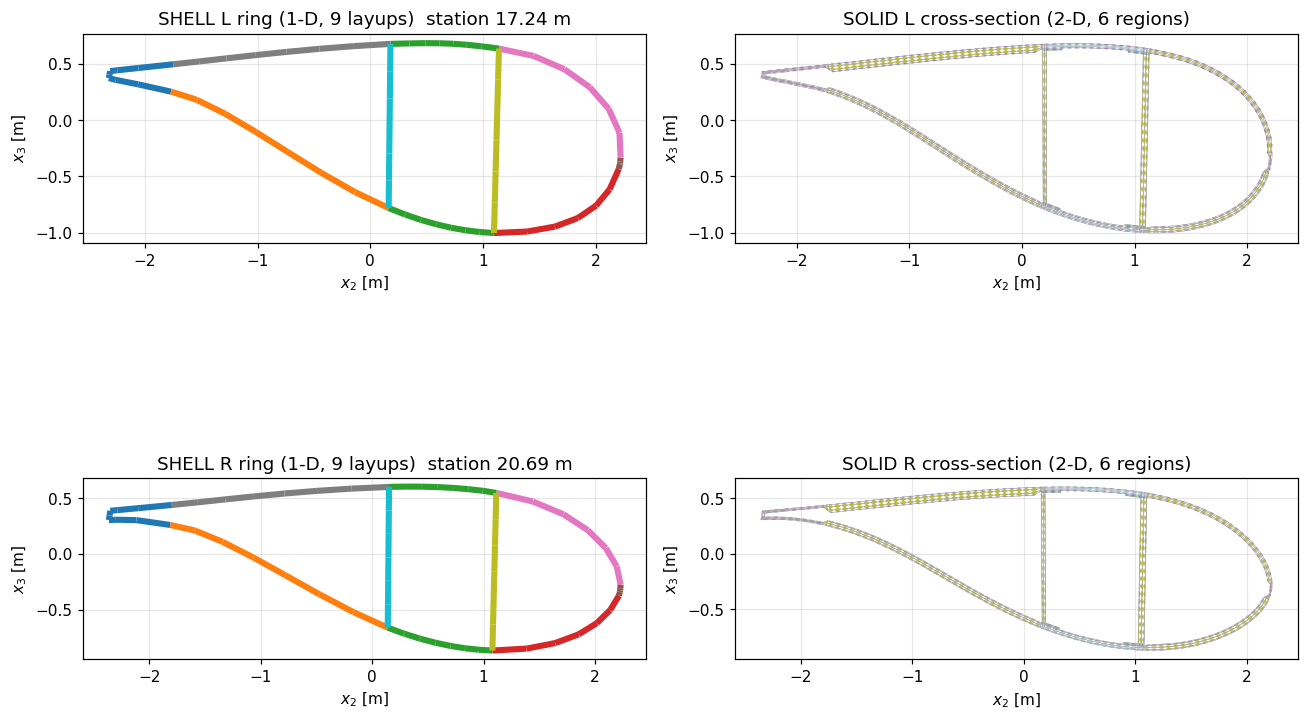

In [4]:
plot_meshes(b5, 4)

## Example 2: segment 12 (span 41.38 - 44.83 m)

In [5]:
_ = run_segment(12, 13, 11)

segment frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=5.6e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0439  mean(e3.-r)=0.0168  -> CHECK


free edges 128 -> 2 end cross-section(s)
beam axis = z ; 62/62 nodes on L/R cross-section
  L cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  L-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=3.4e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0387  mean(e3.-r)=0.0151  -> CHECK
  R cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  R-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=2.0e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0439  mean(e3.-r)=0.0159  -> CHECK


wrote C:\Users\bagla0\AppData\Local\Temp\taper3dsg_yd4zpgfk\seg12.npz


segment frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=5.1e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0464  mean(e3.-r)=0.0152  -> CHECK


free edges 128 -> 2 end cross-section(s)
beam axis = z ; 62/62 nodes on L/R cross-section
  L cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  L-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=4.2e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0440  mean(e3.-r)=0.0158  -> CHECK
  R cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  R-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=3.4e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0461  mean(e3.-r)=0.0148  -> CHECK


wrote C:\Users\bagla0\AppData\Local\Temp\taper3dsg_yd4zpgfk\seg13.npz



----- seg 12 LEFT boundary vs solid 11 L -----
  C_ij          shell         solid      %err
  C11      1.4988e+10    1.4743e+10     +1.7%
  C15      2.1307e+08    2.0216e+08     +5.4%
  C16     -4.3424e+09   -4.6031e+09     -5.7%
  C22      6.1591e+08    6.2561e+08     -1.6%
  C44      3.0547e+08    3.2330e+08     -5.5%
  C55      2.9313e+09    2.9105e+09     +0.7%
  C56      6.0430e+08    5.3298e+08    +13.4%
  C66      9.5865e+09    8.7509e+09     +9.5%
----- seg 12 RIGHT boundary FROZEN layup vs solid 11 R -----
  C_ij          shell         solid      %err
  C11      1.4838e+10    1.4315e+10     +3.7%
  C15      2.5945e+08    2.3044e+08    +12.6%
  C16     -4.0632e+09   -4.3710e+09     -7.0%
  C22      5.9379e+08    5.4411e+08     +9.1%
  C44      2.5025e+08    2.4251e+08     +3.2%
  C55      2.4778e+09    2.4431e+09     +1.4%
  C56      4.4999e+08    3.5992e+08    +25.0%
  C66      8.3634e+09    7.1851e+09    +16.4%
----- seg 12 RIGHT boundary TRUE layup (= seg 13 L) vs solid 11

## Example 3: segment 15 (span 51.72 - 55.17 m)

Here the layup taper fixes $C_{11},C_{44},C_{55}$ and the shear terms, but a **residual
$C_{66}$** (edgewise, $\sim$18%) remains. This is **not** a taper artifact: it is already present
at the one-to-one *left* boundary (true layup) and grows outboard &mdash; the BAR-URC flatback
trailing-edge representation in the shell model, the same effect seen in the full-blade
OpenFAST comparison.

In [6]:
_ = run_segment(15, 16, 14)

segment frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=6.6e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0448  mean(e3.-r)=0.0140  -> CHECK


free edges 128 -> 2 end cross-section(s)
beam axis = z ; 62/62 nodes on L/R cross-section
  L cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  L-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=5.3e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0448  mean(e3.-r)=0.0142  -> CHECK
  R cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  R-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=3.5e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0408  mean(e3.-r)=0.0137  -> CHECK


wrote C:\Users\bagla0\AppData\Local\Temp\taper3dsg_yd4zpgfk\seg15.npz


segment frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=6.6e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0402  mean(e3.-r)=0.0135  -> CHECK


free edges 128 -> 2 end cross-section(s)
beam axis = z ; 62/62 nodes on L/R cross-section
  L cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  L-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=5.7e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0402  mean(e3.-r)=0.0137  -> CHECK
  R cross-section: 62 nodes, 64 edges, 4 junctions(deg>2)
  R-ring frame: |e1|=1.0000 |e2|=1.0000 |e3|=1.0000  max|off-diag|=4.8e-16  RH(e1xe2.e3) in [1.000,1.000]  min(e1.x)=-0.0341  mean(e3.-r)=0.0133  -> CHECK


wrote C:\Users\bagla0\AppData\Local\Temp\taper3dsg_yd4zpgfk\seg16.npz



----- seg 15 LEFT boundary vs solid 14 L -----
  C_ij          shell         solid      %err
  C11      1.3326e+10    1.3031e+10     +2.3%
  C16     -3.2412e+09   -3.5277e+09     -8.1%
  C22      4.4066e+08    4.5528e+08     -3.2%
  C44      1.4593e+08    1.5426e+08     -5.4%
  C55      1.6711e+09    1.6569e+09     +0.9%
  C56      2.9777e+08    2.5335e+08    +17.5%
  C66      5.8092e+09    5.0609e+09    +14.8%
----- seg 15 RIGHT boundary FROZEN layup vs solid 14 R -----
  C_ij          shell         solid      %err
  C11      1.3201e+10    1.1970e+10    +10.3%
  C15      7.3430e+07    2.8321e+08    -74.1%
  C16     -2.9699e+09   -2.9999e+09     -1.0%
  C22      4.3196e+08    3.8330e+08    +12.7%
  C55      1.3942e+09    1.3082e+09     +6.6%
  C56      2.0873e+08    8.4211e+07   +147.9%
  C66      5.1082e+09    4.1209e+09    +24.0%
----- seg 15 RIGHT boundary TRUE layup (= seg 16 L) vs solid 14 R -----
  C_ij          shell         solid      %err
  C11      1.2236e+10    1.1970e+10  

## Writer-independence check: JAX vs OpenSG boundary YAML

The same physical cross-section (segment 5's right end, 20.69 m) written by **two different
tools** &mdash; our topological extractor and the official OpenSG
`ShellSegmentMesh._create_1Dyaml` &mdash; differs only in node/element *ordering* and
orientation-frame convention. `solve_1dyaml` canonicalizes both, so the two files give the
**same** Timoshenko $6\times6$:

In [7]:
from solve_1dyaml import solve as solve_1d

D1 = os.path.join(CC, "examples", "data", "1d_yaml")
A = solve_1d(os.path.join(D1, "bar_urc_seg5R_jax1d.yaml"), center_ref=False, verbose=True)
B = solve_1d(os.path.join(D1, "bar_urc_seg5R_opensg1d.yaml"), center_ref=False, verbose=True)
print("diag A x1e9:", np.array2string(np.diag(A) / 1e9, precision=4))
print("diag B x1e9:", np.array2string(np.diag(B) / 1e9, precision=4))
reldiff = np.max(np.abs(A - B)) / np.max(np.abs(A))
print("max |A-B| / max|A| = %.2e   (identical mesh content up to reordering)" % reldiff)
assert reldiff < 1e-5

  bar_urc_seg5R_jax1d.yaml: 62 nodes, 64 edges (2 flipped), 9 sections, k22[geom] range [-16.750, 16.478]


  bar_urc_seg5R_opensg1d.yaml: 62 nodes, 64 edges (2 flipped), 9 sections, k22[geom] range [-16.750, 16.478]
diag A x1e9: [14.6948  1.4729  0.3949  1.4407  5.183  18.1201]
diag B x1e9: [14.6948  1.4729  0.3949  1.4407  5.183  18.1201]
max |A-B| / max|A| = 4.27e-07   (identical mesh content up to reordering)


## Summary

- The OpenSG shell mesh **freezes each segment's layup at its inboard reference**, so a
  segment's *right* boundary is **not** one-to-one with the solid ($C_{11}$ +8%, $C_{66}$ +21%
  for segment 5). Using the true outboard layup &mdash; the next segment's *left* ring, sharing
  the same face &mdash; restores the one-to-one match to $\sim$1%.
- **`compute_timo_taper_layup`** blends the per-quad ABD from segment $N$ to $N{+}1$ across the
  span, so the tapered $6\times6$ tracks the solid on $C_{11},C_{44},C_{55}$ and the shear terms
  ($\lesssim 6\%$), a clear improvement over the frozen-layup taper ($C_{22}$ +13% $\to$ +1%,
  $C_{44}$ +8% $\to$ &minus;3% for segment 5).
- **Timing**: the shell (JAX-RM) $6\times6$ costs $\sim$1 minute per segment; the FEniCS 3-D
  solid costs several minutes &mdash; a several-fold speed-up (reported per segment above), for
  a full $6\times6$ that agrees to a few percent on the terms the shell cross-section can
  represent.
- The **residual $C_{66}$** (edgewise) grows outboard and is **data/model-level** (the shell vs
  solid flatback trailing-edge difference), present at the one-to-one left boundary too, not a
  property of the tapered-segment machinery.
- The JAX and official-OpenSG boundary YAMLs of the same cross-section agree to $\sim 10^{-7}$.